<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-6---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Modulo_VI_Equipo_15_Habits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea Módulo VI - Aprendizaje No Supervisado**

**Metodologías:**

*   Principal Component Analysis (PCA)
*   t-Distributed Stochastic Neighbor Embedding (t-SNE)
*   Uniform Manifold Approximation and Projection (UMAP)

**PENDIENTES**

"Codificar categorías .. No One Hoted ... era ???

In [ ]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
#from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
#from sklearn.compose import ColumnTransformer
import umap
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
# Como queremos una salida más limpia y legible de algunas gráficas importamos lo sig:
import warnings
warnings.filterwarnings("ignore")

# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Importar la información  ya limpia y normalizada
df_habits = pd.read_csv("habits - habits.csv", sep=',', encoding='utf-8')
print(df_habits.shape)
print(df_habits.head(3))
print(df_habits.info())

(1000, 15)
   age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0   23  Female                  0.0                 1.2            1.1   
1   20  Female                  6.9                 2.8            2.3   
2   21    Male                  1.4                 3.1            1.3   

  part_time_job  attendance_percentage  sleep_hours diet_quality  \
0            No                   85.0          8.0         Fair   
1            No                   97.3          4.6         Good   
2            No                   94.8          8.0         Poor   

   exercise_frequency parental_education_level internet_quality  \
0                   6                   Master          Average   
1                   6              High School          Average   
2                   1              High School             Poor   

   mental_health_rating extracurricular_participation  exam_score  
0                     8                           Yes        56.2  
1             

In [ ]:
#Podría haber diferentes decisiones:
# Opción 1: Considerar no utilizar parental_education_level
# Opción 2: Imputar parental_education_level
# Opción 2: Eliminar los 91 registros de lainformación (~10%)

df_habits.isnull().sum()

age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

#PRIMERA SECCIÓN

## EDA

Análisis de las variables cuantitativas
1.   Descripción en tabla
2.   Visualización mediante gráficos de caja y bigotes e histogramas

Análisis de las variables cualitativas
1.   Elemento de lista
2.   Visualización mediante gráficos de barras




In [ ]:
# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64'])
cols_cuantitativas.describe().round(3)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,20.498,3.550,2.506,1.820,84.132,6.470,3.042,5.438,69.602
std,2.308,1.469,1.172,1.075,9.399,1.226,2.025,2.848,16.889
min,17.000,0.000,0.000,0.000,56.000,3.200,0.000,1.000,18.400
25%,18.750,2.600,1.700,1.000,78.000,5.600,1.000,3.000,58.475
50%,20.000,3.500,2.500,1.800,84.400,6.500,3.000,5.000,70.500
75%,23.000,4.500,3.300,2.525,91.025,7.300,5.000,8.000,81.325
max,24.000,8.300,7.200,5.400,100.000,10.000,6.000,10.000,100.000


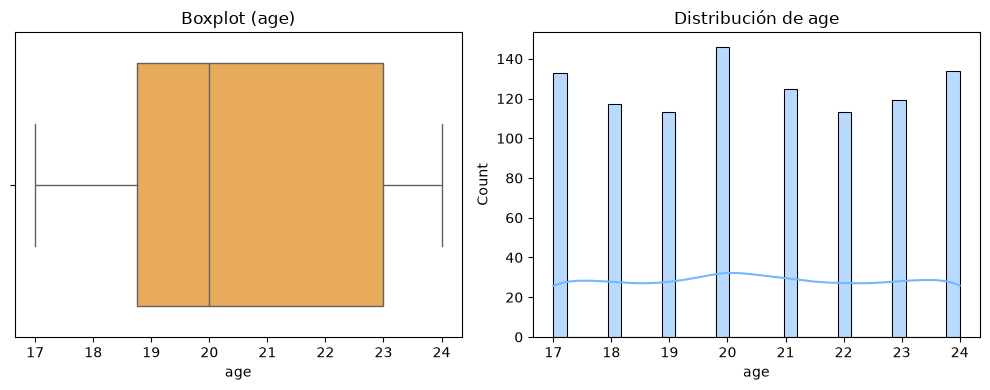

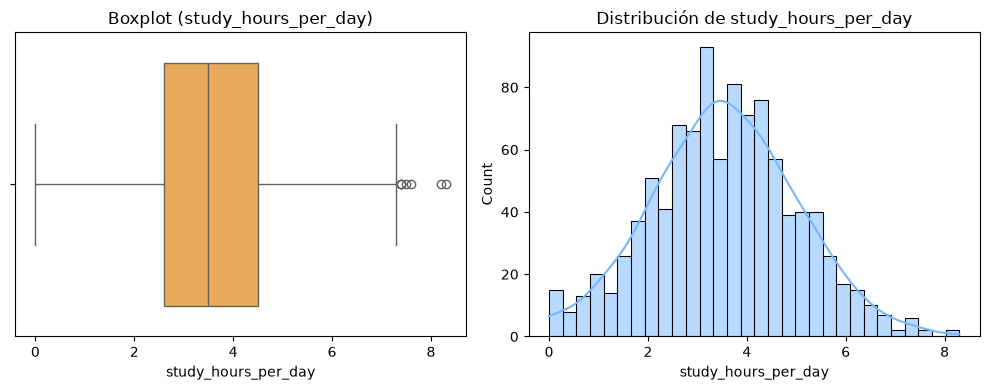

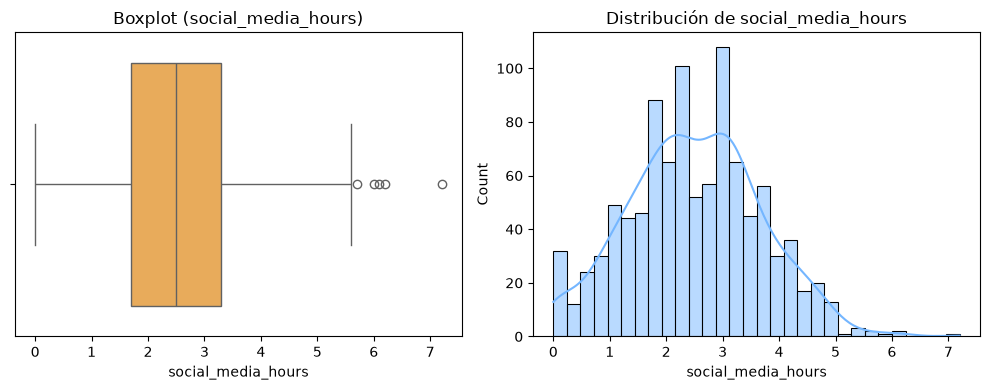

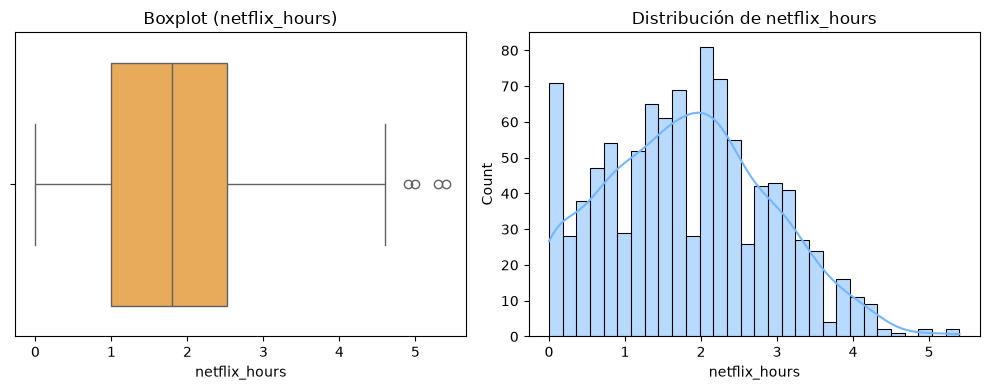

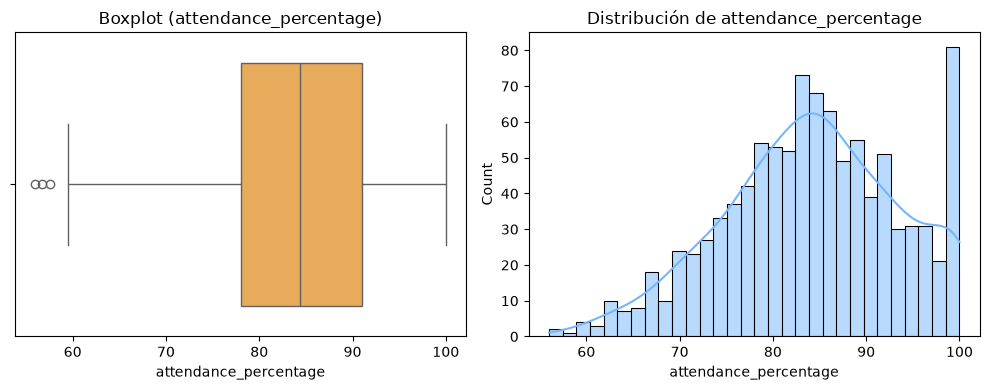

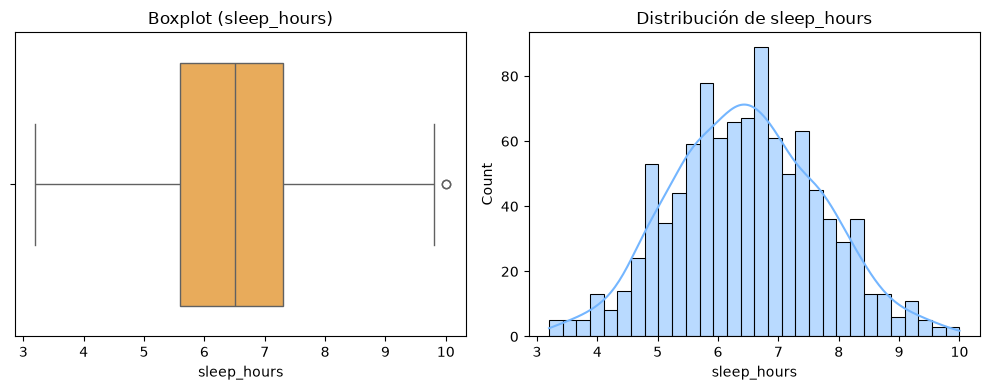

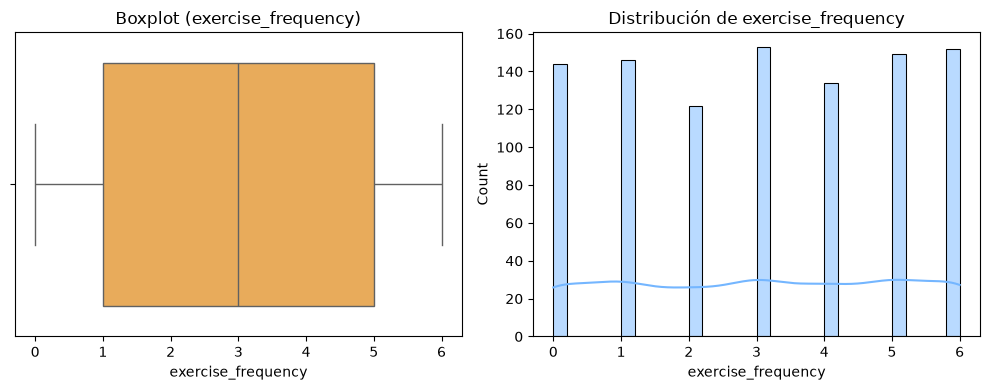

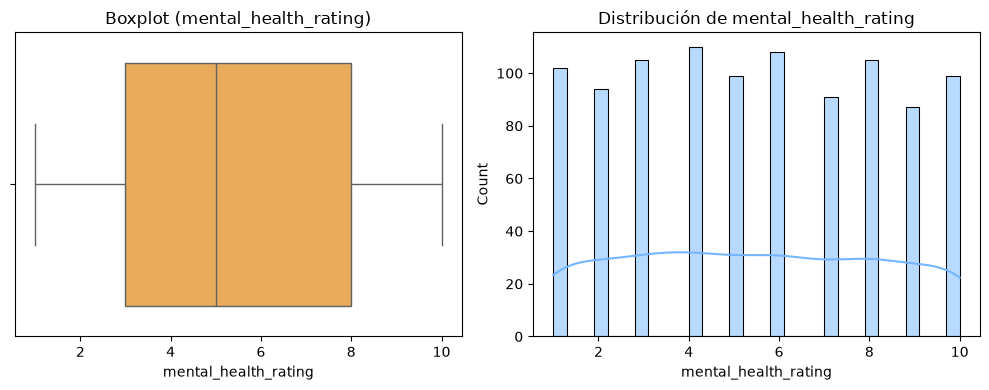

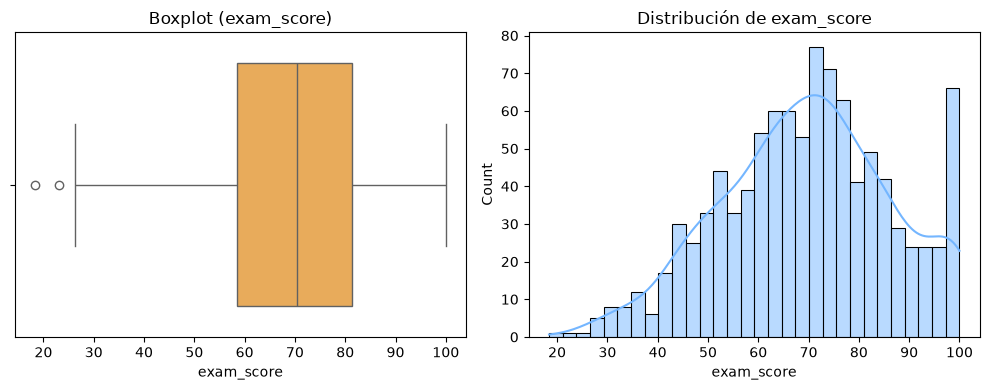

In [ ]:
# HISTOGRAMA Y GRAFICO  DE CAJA Y BIGOTES PARA VARIABLES CUANTITATIVA

# Lista de columnas cuantitativas a analizar
cols_cuantitativas = df_habits.select_dtypes(include=['int64', 'float64']).columns.tolist()
#cols_cuantitativas = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
#                      "attendande_percentage", "sleep_hours", "exercise_frequency", "mental_health_rating ",
#                      "exam_score"
#                      ]

# Iterar sobre cada columna y graficar
for col in cols_cuantitativas:
    plt.figure(figsize=(10, 4))  # tamaño de la figura

    #Gráfico de caja y bigotes
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_habits[col], color="#ffae44") #  palette="viridis"
    plt.title(f"Boxplot ({col})")

    # Gráfico para el histograma identificar sesgos o valores atípicos (outliers)
    plt.subplot(1, 2, 2)
    sns.histplot(df_habits[col], bins=30, color="#74b6ff", kde=True) #palette="viridis"
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

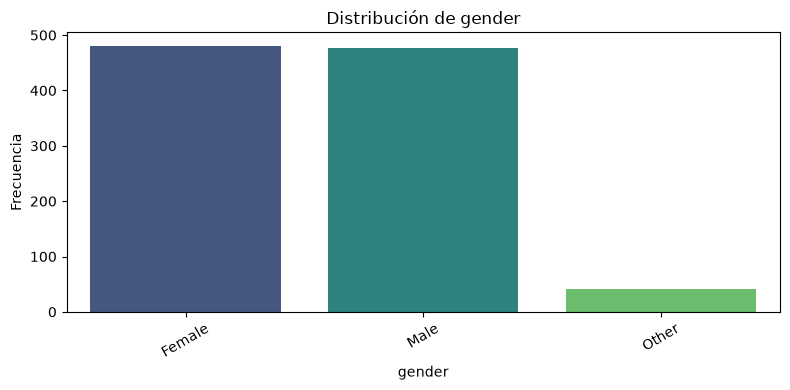

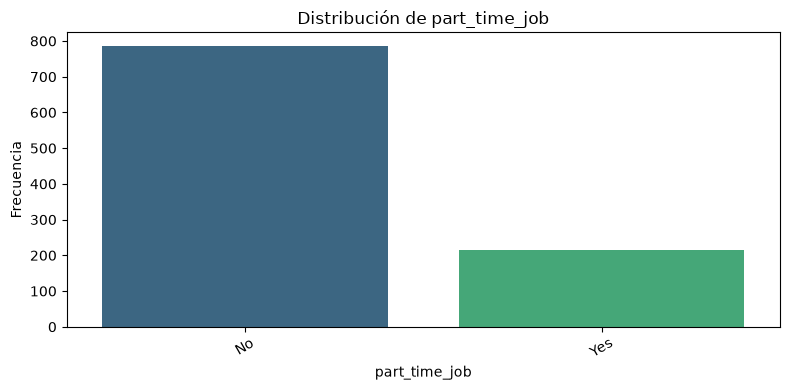

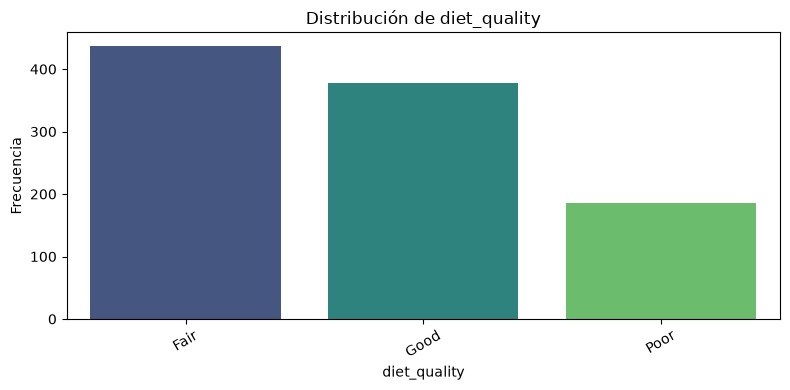

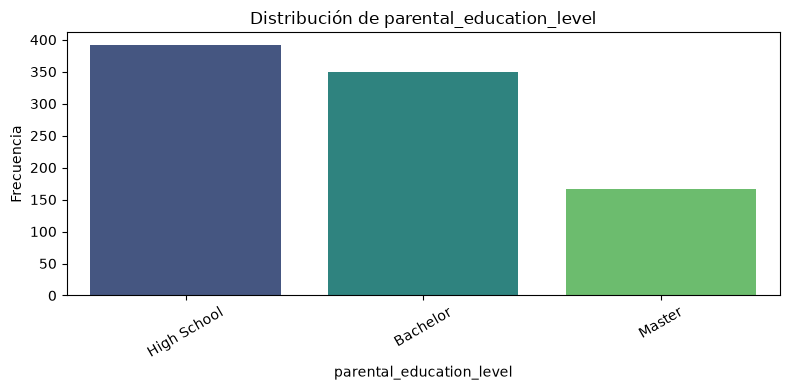

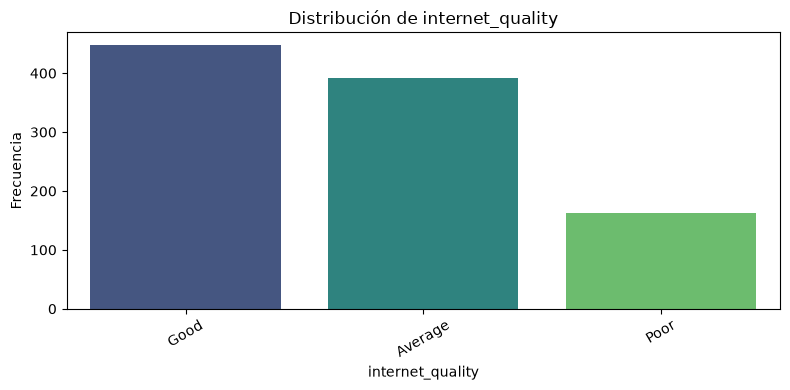

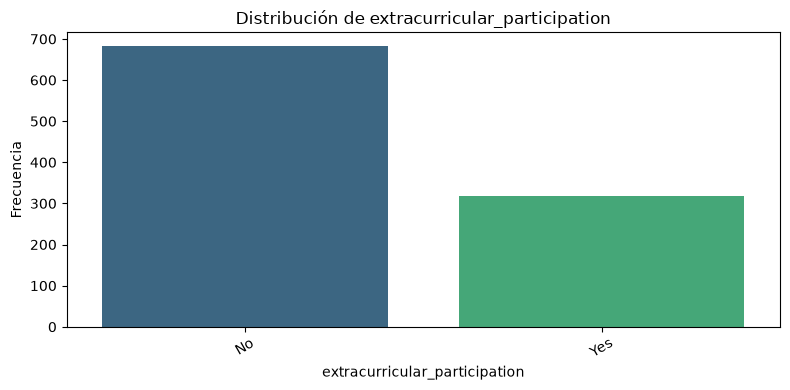

In [ ]:
# GRAFICO  DE BARRAS PARA VARIABLES CUALITATIVA

# Lista de columnas cuantitativas a analizar
cols_cualitativas = df_habits.select_dtypes(include=['object', 'category']).columns.tolist()

# Iterar sobre cada columna y graficar
for col in cols_cualitativas:
    plt.figure(figsize=(8, 4))

    # Conteo de categorías
    counts = df_habits[col].value_counts()

    # Gráfico de barras
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Frecuencia")
    plt.xlabel(col)
    plt.xticks(rotation=30)  # rotar etiquetas si son largas

    plt.tight_layout()
    plt.show()

# Preprocesamiento y Modelos de agrup...




In [ ]:
# Aqui observamos los datos unicos por columna.
cols = pd.Series(df_habits.columns)

for i in cols:
    print("Columna: ", i)
    display(df_habits[i].unique())
    print("\n")



Columna:  age


array([23, 20, 21, 19, 24, 18, 22, 17])



Columna:  gender


<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str



Columna:  study_hours_per_day


...

array([ 8,  1,  4, 10,  3,  9,  7,  5,  2,  6])



Columna:  extracurricular_participation


<StringArray>
['Yes', 'No']
Length: 2, dtype: str



Columna:  exam_score


array([ 56.2, 100. ,  34.3,  26.8,  66.4,  89.8,  72.6,  78.9,  63.3,
        74.4,  76.9,  75.8,  74. ,  55.2,  70.8,  43.9,  45.3,  58.5,
        82.5,  98.7,  43.7,  54.9,  69.9,  73.5,  71.1,  82.8,  75.7,
        70.6,  51.3,  52.1,  70.7,  51.2,  59.4,  58.1,  82.3,  69.7,
        66. ,  63.5,  65.7,  78.5,  75.1,  71. ,  59.7,  52.6,  96.5,
        62. ,  48.4,  68.1,  87.2,  66.7,  75.2,  46.4,  97.1,  61.2,
        75. ,  94.7,  77.6,  68.6,  69.6,  66.5,  62.2,  82.1,  55.1,
        77.1,  97.7,  66.9,  99.9,  57.2,  77.3,  91.6,  57.6,  60.2,
        50.5,  53.5,  79.2,  47.2,  73.4,  41.1,  77.8,  63.4,  70.2,
        81.3,  50.2,  87.9,  80.9,  63.9,  65.6,  93.2,  60.8,  50.4,
        74.3,  32.8,  60.4,  60. ,  77.5,  86.5,  83.3,  82.7,  94.8,
        80.8,  58.3,  66.3,  60.5,  84.8,  77. ,  61.7,  44. ,  42.4,
        88. ,  48.7,  81.6,  78.4,  67.6,  64.7,  64.1,  83.5,  96.2,
        65.4,  46.7,  75.5,  78.1,  85.2,  75.4,  64.2,  90.3,  81.4,
        65. ,  57.3,

In [ ]:
exam_scores = df_habits['exam_score'].copy()

X = df_habits.drop(columns=['exam_score'])

# esto es mejor que el one-hot, dado que mantenemos más baja la dimensionalidad
X['part_time_job'] = X['part_time_job'].map({'No': 0, 'Yes': 1})
X['extracurricular_participation'] = X['extracurricular_participation'].map({'No': 0, 'Yes': 1})

diet_categories = ['Poor', 'Fair', 'Good']
internet_categories = ['Poor', 'Average', 'Good']
# Observamos la columna parental_education_level es la única con NaN.
# Cambiamos NaN a string "Unknown"
education_categories = ['High School', 'Bachelor', 'Master', "Unknown"]

col_education = ['parental_education_level']
cols_other_ordinal = ['diet_quality', 'internet_quality']
cols_nominal = ['gender']
cols_numeric = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
                'attendance_percentage', 'sleep_hours', 'exercise_frequency',
                'mental_health_rating', 'part_time_job', 'extracurricular_participation']

education_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ordinal', OrdinalEncoder(categories=[education_categories]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_numeric),
        ('edu_ord', education_pipeline, col_education), # Usamos education_pipline
        ('other_ord', OrdinalEncoder(categories=[diet_categories, internet_categories]), cols_other_ordinal),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), cols_nominal)
    ],
    remainder='passthrough'
)

pipeline_final = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('scaler_final', StandardScaler())
])

X_procesado_array = pipeline_final.fit_transform(X)

In [ ]:
# Esto es simplemente para ver el dataframe trasformado, por si nos es útil para el reporte
# ya que los piplines lo convierte a arranges abstractos sin nombres.

nombres_columnas = pipeline_final.named_steps['preprocess'].get_feature_names_out()
df_procesado = pd.DataFrame(X_procesado_array, columns=nombres_columnas)

display(df_procesado.head())

,num__age,num__study_hours_per_day,num__social_media_hours,num__netflix_hours,num__attendance_percentage,num__sleep_hours,num__exercise_frequency,num__mental_health_rating,num__part_time_job,num__extracurricular_participation,edu_ord__parental_education_level,other_ord__diet_quality,other_ord__internet_quality,nom__gender_Male,nom__gender_Other
0,1.084551,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,-0.523341,1.464464,1.086723,-0.266175,-0.392302,-0.955011,-0.209383
1,-0.215870,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,-0.523341,-0.682844,-0.997118,1.112970,-0.392302,-0.955011,-0.209383
2,0.217604,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,-0.523341,-0.682844,-0.997118,-1.645320,-1.768800,1.047108,-0.209383
3,1.084551,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,-0.523341,1.464464,1.086723,-1.645320,0.984196,-0.955011,-0.209383
4,-0.649344,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,-0.523341,-0.682844,1.086723,-0.266175,0.984196,-0.955011,-0.209383


In [ ]:
# Eliminando valores missing
habits_nomiss = df_habits.dropna()
print(habits_nomiss)

     age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0     23  Female                  0.0                 1.2            1.1   
1     20  Female                  6.9                 2.8            2.3   
2     21    Male                  1.4                 3.1            1.3   
3     23  Female                  1.0                 3.9            1.0   
4     19  Female                  5.0                 4.4            0.5   
..   ...     ...                  ...                 ...            ...   
995   21  Female                  2.6                 0.5            1.6   
996   17  Female                  2.9                 1.0            2.4   
997   20    Male                  3.0                 2.6            1.3   
998   24    Male                  5.4                 4.1            1.1   
999   19  Female                  4.3                 2.9            1.9   

    part_time_job  attendance_percentage  sleep_hours diet_quality  \
0              No

In [ ]:
# UMAP sin especificar hiper-parámetros (valores por defecto)

# tomamos las variables numericas
numeric_cols = habits_nomiss.select_dtypes(include=[np.number]).columns
# print(numeric_cols)
Scaled_habits_data = StandardScaler().fit_transform(habits_nomiss[numeric_cols])
# print(type(Scaled_habits_data), Scaled_habits_data.shape)

reducer = umap.UMAP(random_state=42) # con semilla, para que no mueva los resultados
df_umap = reducer.fit_transform(Scaled_habits_data)
# Resultados
print(type(df_umap), df_umap.shape)
print(df_umap[:5])

# # Version pingüinos
# plt.scatter(
#     df_umap[:, 0],
#     df_umap[:, 1],
#     c=[sns.color_palette()[x] for x in habits_nomiss[["age"]]])
# plt.gca().set_aspect('equal', 'datalim')
# plt.title('UMAP projection of the Penguin dataset', fontsize=24);

<class 'numpy.ndarray'> (909, 2)
[[10.216055   5.778007 ]
 [ 4.44742    4.939366 ]
 [10.067235   4.0047736]
 [10.17219    4.918353 ]
 [ 8.200964   3.097814 ]]


In [ ]:
# Para que podamos tomar la variable de "Calificaciones" la segmentamos en quartiles:
habits_nomiss["exam_quartile"] = pd.qcut(
    habits_nomiss["exam_score"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

bins = [0, 3, 5.9, 8, 10]   # límites de los intervalos
labels = ["0-3", "3-5.9", "6-8", "8-10"]

# Verificar resultado
print(habits_nomiss[["exam_score", "exam_quartile"]].head())

   exam_score exam_quartile
0        56.2            Q1
1       100.0            Q4
2        34.3            Q1
3        26.8            Q1
4        66.4            Q2


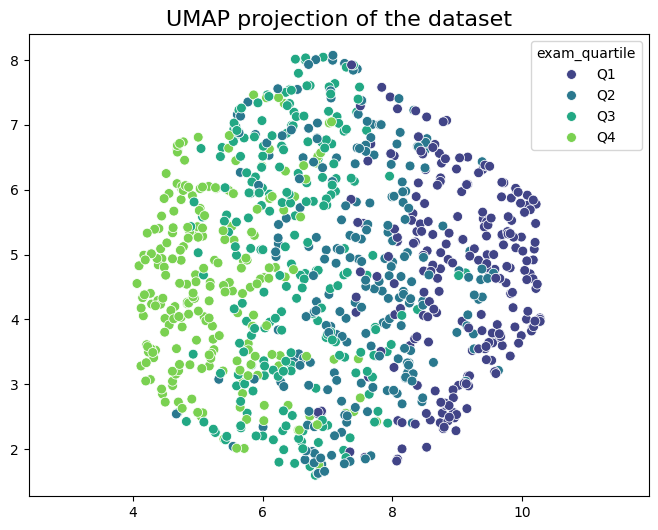

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_umap[:, 0],
    y=df_umap[:, 1],
    hue=habits_nomiss["exam_quartile"],   # aquí pasas la variable
    palette="viridis",          # paleta de colores
    s=50                        # tamaño de los puntos
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the dataset', fontsize=16)
plt.legend(title="exam_quartile")
plt.show()

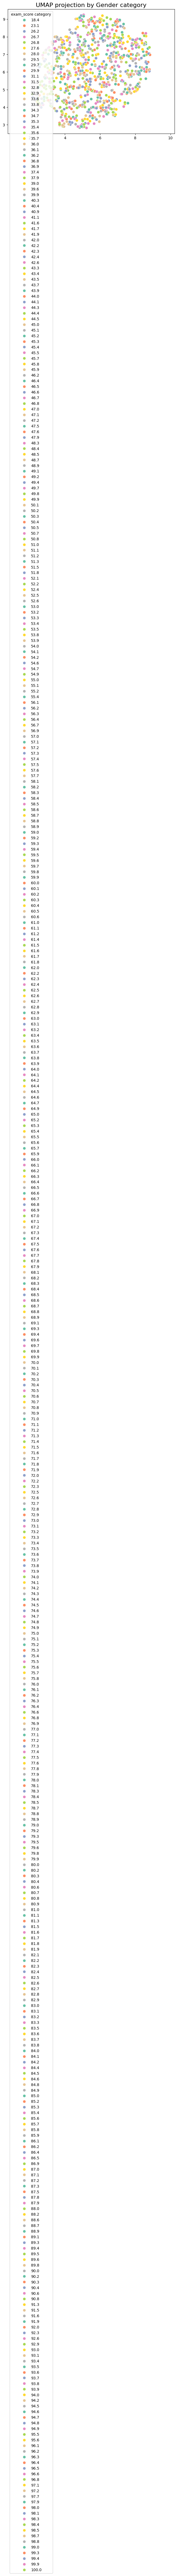

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_umap[:, 0],
    y=df_umap[:, 1],
    hue=habits_nomiss["exam_score"],   # variable categórica
    palette="Set2",             # paleta discreta (Set1, Set2, Paired, etc.)
    s=60
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection by exam_score category', fontsize=16)
plt.legend(title="exam_score category")
plt.show()

In [ ]:
habits_nomiss[["gender"]]
#  ({"Female":0,"Male":1,"Other":2})

,gender
0,Female
1,Female
2,Male
3,Female
4,Female
...,...
995,Female
996,Female
997,Male
998,Male
